In [7]:
from google.colab import files
uploaded = files.upload()

Saving fitness_health_data.csv to fitness_health_data.csv


In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

# Plain text dataframe output (avoids GitHub notebook viewer issues)
pd.set_option("display.notebook_repr_html", False)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)

DATA_PATH = "fitness_health_data.csv"
CHARTS_DIR = "charts"
RESULTS_DIR = "results"
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_chart(fig, filename):
    fig.savefig(os.path.join(CHARTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
df = pd.read_csv(DATA_PATH)
df.head(10)

Record ID  User ID      User Name  Age  Gender        City  Height (cm)  Weight (kg)     Workout Type  \
0          1       54  Sana Siddiqui   19  Female   Islamabad        162.5         60.4             Yoga   
1          2       41      Sara Shah   19    Male      Lahore        181.2         72.6  Weight Training   
2          3       16      Asad Butt   30    Male  Rawalpindi          0.0         72.9           Cardio   
3          4       60     Hamza Khan   52  Female    Peshawar        149.5         50.4           Cardio   
4          5       60     Hamza Khan   52  Female    Peshawar        149.5         50.4         Swimming   
5          6        9   Imran Farooq   38  Female      Multan        151.7         56.4         Swimming   
6          7       45     Asad Iqbal   39  Female      Multan        164.5         45.0         Swimming   
7          8       53   Ayesha Ahmed   48    Male      Multan        197.3         79.0           Cardio   
8          9       26    Junaid Butt   36  Female  Faisalabad        168.2         72.3          Cycling   
9         10       44     Sara Ahmed   49  Female      Lahore        158.6         66.0  Weight Training   

   Workout Duration (Minutes)  Calories Burned  Steps  Heart Rate (BPM)  Resting Heart Rate (BPM)  Sleep Hours  \
0                        61.8            226.0   7368             132.0                        73          5.3   
1                        49.0            353.5  13447             127.0                        70          6.5   
2                        71.2            631.3  16951             108.0                        55          6.1   
3                        56.0            604.5   6146             121.0                        66          8.3   
4                        61.5            580.0   8353             150.0                        63          7.4   
5                        47.9            438.9   7073             134.0                        72          7.1   
6                        58.3            738.8   3405             128.0                        65          7.6   
7                        49.4            488.0   4807             108.0                        53          4.9   
8                        46.9            482.0   6330             143.0                        77          4.5   
9                        50.4            355.4   6628             148.0                        69          6.6   

   Water Intake (Liters)  Daily Calories Intake  Workout Frequency Fitness Level Activity Date  
0                   4.98                   2211                  7      Advanced    2025-08-28  
1                   0.30                   2208                  5      Advanced    2025-11-19  
2                   2.46                   2297                  4      Advanced    2025-10-08  
3                   2.55                   3066                  6  Intermediate    2025-05-04  
4                   3.90                   2568                  4  Intermediate    2025-03-25  
5                   0.51                   2169                  6  Intermediate    2025-05-07  
6                   2.67                   2058                  3  Intermediate    2025-04-21  
7                   2.40                   3042                  6      Beginner    2025-02-23  
8                   1.99                   2624                  4  Intermediate    2025-03-06  
9                   3.19                   2502                  4      Beginner    2025-04-17

In [10]:
df.tail(10)

Record ID  User ID         User Name  Age  Gender        City  Height (cm)  Weight (kg) Workout Type  \
316        317       54     Sana Siddiqui   19  Female   Islamabad        162.5         60.4         HIIT   
317        318       18    Sadia Siddiqui   45    Male      Lahore        180.1         74.9         HIIT   
318        319       18    Sadia Siddiqui   45    Male         NaN        180.1         74.9      Running   
319        320       28       Imran Ahmed   40    Male    Peshawar        188.1         82.8      Walking   
320        321       45        Asad Iqbal   39  Female      Multan        164.5         45.0      Walking   
321        322        6     Mahnoor Ahmed   26    Male  Faisalabad        180.5         64.8      Running   
322        323       34        Hamza Khan  130    Male  Rawalpindi        179.4        114.7         Yoga   
323        324        4       Junaid Shah   45    Male  Faisalabad        176.6         68.8      Walking   
324        325       10  Mahnoor Chaudhry   46    Male   Islamabad        179.1         88.7      Walking   
325        326       18    Sadia Siddiqui   45    Male      Lahore        180.1         74.9         HIIT   

     Workout Duration (Minutes)  Calories Burned  Steps  Heart Rate (BPM)  Resting Heart Rate (BPM)  Sleep Hours  \
316                        84.6           1043.1   7845               NaN                        71          4.6   
317                        36.3            630.8   8902             145.0                        74          8.2   
318                        58.3            703.8   3399             158.0                        60          6.3   
319                        25.3             72.9   7230             155.0                        67          7.3   
320                        33.4            161.6   5219             130.0                        70          8.0   
321                        10.0            107.0  12677             132.0                        74          7.1   
322                        53.5            157.1   6372             126.0                        76          8.1   
323                        66.9            260.3  12471             152.0                        64          5.2   
324                        69.9            248.7   4230             134.0                        76          5.9   
325                        26.3            296.8   5877             142.0                        65          9.6   

     Water Intake (Liters)  Daily Calories Intake  Workout Frequency Fitness Level Activity Date  
316                   3.15                   1594                  3      Advanced    2025-04-18  
317                   2.31                   2314                  5      Beginner    2025-06-15  
318                   1.58                   2302                  6      Beginner    2025-06-10  
319                   2.15                   2258                  7  Intermediate    2025-03-27  
320                   4.07                   2019                  4  Intermediate    2025-06-22  
321                   1.97                   1303                  3  Intermediate    2025-12-23  
322                   1.97                   1994                  7      Beginner    2025-10-12  
323                   2.72                   1954                  7  Intermediate    2025-07-29  
324                   1.30                   2163                  7      Advanced    2025-04-08  
325                   3.22                   2047                  3      Beginner    2025-06-21

In [11]:
print("Shape:", df.shape)
df.info()

Shape: (326, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record ID                   326 non-null    int64  
 1   User ID                     326 non-null    int64  
 2   User Name                   326 non-null    object 
 3   Age                         326 non-null    int64  
 4   Gender                      326 non-null    object 
 5   City                        323 non-null    object 
 6   Height (cm)                 326 non-null    float64
 7   Weight (kg)                 326 non-null    float64
 8   Workout Type                326 non-null    object 
 9   Workout Duration (Minutes)  326 non-null    float64
 10  Calories Burned             320 non-null    float64
 11  Steps                       326 non-null    int64  
 12  Heart Rate (BPM)            322 non-null    float64
 13  Resting Heart Rate

In [12]:
print("Columns:", list(df.columns))
df.describe(include="all").T

Columns: ['Record ID', 'User ID', 'User Name', 'Age', 'Gender', 'City', 'Height (cm)', 'Weight (kg)', 'Workout Type', 'Workout Duration (Minutes)', 'Calories Burned', 'Steps', 'Heart Rate (BPM)', 'Resting Heart Rate (BPM)', 'Sleep Hours', 'Water Intake (Liters)', 'Daily Calories Intake', 'Workout Frequency', 'Fitness Level', 'Activity Date']


count unique           top freq         mean          std     min      25%     50%  \
Record ID                   326.0    NaN           NaN  NaN        163.5    94.252321     1.0    82.25   163.5   
User ID                     326.0    NaN           NaN  NaN    30.763804     17.42949     1.0     16.0    30.5   
User Name                     326     51    Hamza Khan   28          NaN          NaN     NaN      NaN     NaN   
Age                         326.0    NaN           NaN  NaN     42.53681    14.227931    -5.0     34.0    45.0   
Gender                        326      2          Male  198          NaN          NaN     NaN      NaN     NaN   
City                          323      8      Peshawar   53          NaN          NaN     NaN      NaN     NaN   
Height (cm)                 326.0    NaN           NaN  NaN   171.693558    17.741274     0.0    165.7   171.6   
Weight (kg)                 326.0    NaN           NaN  NaN    71.734969     15.33703   -10.0     62.1    71.2   
Workout Type                  326      8       Walking   51          NaN          NaN     NaN      NaN     NaN   
Workout Duration (Minutes)  326.0    NaN           NaN  NaN    46.521472    18.689549    10.0   32.725   44.45   
Calories Burned             320.0    NaN           NaN  NaN   358.019375   232.582151   -50.0  182.075   304.2   
Steps                       326.0    NaN           NaN  NaN  7879.515337  3646.963579   500.0   5406.0  7217.0   
Heart Rate (BPM)            322.0    NaN           NaN  NaN   129.714286    24.252804     0.0    116.0   130.0   
Resting Heart Rate (BPM)    326.0    NaN           NaN  NaN    67.533742     7.989826    45.0     62.0    68.0   
Sleep Hours                 320.0    NaN           NaN  NaN     7.004063     1.882659    -1.0      6.0     7.0   
Water Intake (Liters)       322.0    NaN           NaN  NaN     2.400839     0.832775    -2.0     1.92     2.4   
Daily Calories Intake       326.0    NaN           NaN  NaN  2214.542945   403.572138  1200.0  1961.25  2209.5   
Workout Frequency           326.0    NaN           NaN  NaN     4.699387     1.699357     1.0      3.0     5.0   
Fitness Level                 326      4  Intermediate  159          NaN          NaN     NaN      NaN     NaN   
Activity Date                 326    215    2025-03-30    6          NaN          NaN     NaN      NaN     NaN   

                                75%      max  
Record ID                    244.75    326.0  
User ID                        45.0     60.0  
User Name                       NaN      NaN  
Age                            52.0    130.0  
Gender                          NaN      NaN  
City                            NaN      NaN  
Height (cm)                  179.55    350.0  
Weight (kg)                  81.875    114.7  
Workout Type                    NaN      NaN  
Workout Duration (Minutes)   58.375    106.6  
Calories Burned              481.85   1164.4  
Steps                        9876.0  20599.0  
Heart Rate (BPM)              145.0    300.0  
Resting Heart Rate (BPM)       73.0     88.0  
Sleep Hours                     7.9     30.0  
Water Intake (Liters)         2.925     4.98  
Daily Calories Intake       2495.75   3800.0  
Workout Frequency               6.0      7.0  
Fitness Level                   NaN      NaN  
Activity Date                   NaN      NaN

In [13]:
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])
print("Total missing values:", int(missing_counts.sum()))

City                     3
Calories Burned          6
Heart Rate (BPM)         4
Sleep Hours              6
Water Intake (Liters)    4
dtype: int64
Total missing values: 23


In [14]:
dup_count = df.duplicated().sum()
print("Duplicate records found:", dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Duplicate records found: 0
Rows after removing duplicates: 326


In [15]:
invalid_ages = df[(df["Age"] < 10) | (df["Age"] > 100)]
invalid_height = df[(df["Height (cm)"] < 100) | (df["Height (cm)"] > 230)]
invalid_weight = df[(df["Weight (kg)"] < 30) | (df["Weight (kg)"] > 250)]
negative_calories = df[df["Calories Burned"] < 0]
invalid_hr = df[(df["Heart Rate (BPM)"] < 30) | (df["Heart Rate (BPM)"] > 220)]
invalid_sleep = df[(df["Sleep Hours"] < 0) | (df["Sleep Hours"] > 16)]
invalid_water = df[(df["Water Intake (Liters)"] < 0) | (df["Water Intake (Liters)"] > 10)]

print("Invalid ages:", len(invalid_ages))
print("Invalid heights:", len(invalid_height))
print("Invalid weights:", len(invalid_weight))
print("Negative calories:", len(negative_calories))
print("Invalid heart rates:", len(invalid_hr))
print("Invalid sleep hours:", len(invalid_sleep))
print("Invalid water intake:", len(invalid_water))

Invalid ages: 3
Invalid heights: 2
Invalid weights: 1
Negative calories: 2
Invalid heart rates: 3
Invalid sleep hours: 2
Invalid water intake: 2


In [16]:
for col in ["Calories Burned", "Sleep Hours", "Water Intake (Liters)", "Heart Rate (BPM)"]:
    df[col] = df[col].fillna(df[col].median())

df["City"] = df["City"].fillna(df["City"].mode()[0])

df.loc[(df["Age"] < 10) | (df["Age"] > 100), "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median()).astype(int)

df.loc[(df["Height (cm)"] < 100) | (df["Height (cm)"] > 230), "Height (cm)"] = np.nan
df["Height (cm)"] = df["Height (cm)"].fillna(df["Height (cm)"].median())

df.loc[(df["Weight (kg)"] < 30) | (df["Weight (kg)"] > 250), "Weight (kg)"] = np.nan
df["Weight (kg)"] = df["Weight (kg)"].fillna(df["Weight (kg)"].median())

df.loc[df["Calories Burned"] < 0, "Calories Burned"] = df["Calories Burned"].median()
df.loc[(df["Heart Rate (BPM)"] < 30) | (df["Heart Rate (BPM)"] > 220), "Heart Rate (BPM)"] = df["Heart Rate (BPM)"].median()
df.loc[(df["Sleep Hours"] < 0) | (df["Sleep Hours"] > 16), "Sleep Hours"] = df["Sleep Hours"].median()
df.loc[(df["Water Intake (Liters)"] < 0) | (df["Water Intake (Liters)"] > 10), "Water Intake (Liters)"] = df["Water Intake (Liters)"].median()

print("Missing values remaining:", int(df.isnull().sum().sum()))

Missing values remaining: 0


In [82]:
df["Activity Date"] = pd.to_datetime(df["Activity Date"])

int_cols = ["Age", "Steps", "Heart Rate (BPM)", "Resting Heart Rate (BPM)",
            "Daily Calories Intake", "Workout Frequency"]
for col in int_cols:
    df[col] = df[col].round().astype(int)

float_cols = ["Height (cm)", "Weight (kg)", "Workout Duration (Minutes)",
              "Calories Burned", "Sleep Hours", "Water Intake (Liters)"]
for col in float_cols:
    df[col] = df[col].astype(float)

print("Cleaned dataset shape:", df.shape)
print(df.dtypes)

Cleaned dataset shape: (326, 31)
Record ID                              int64
User ID                                int64
User Name                             object
Age                                    int64
Gender                                object
City                                  object
Height (cm)                          float64
Weight (kg)                          float64
Workout Type                          object
Workout Duration (Minutes)           float64
Calories Burned                      float64
Steps                                  int64
Heart Rate (BPM)                       int64
Resting Heart Rate (BPM)               int64
Sleep Hours                          float64
Water Intake (Liters)                float64
Daily Calories Intake                  int64
Workout Frequency                      int64
Fitness Level                         object
Activity Date                 datetime64[ns]
Age Group                           category
BMI                   

In [18]:
print("Total unique users:", df["User ID"].nunique())

oldest = df.loc[df["Age"].idxmax()]
youngest = df.loc[df["Age"].idxmin()]
print(f"Oldest user: {oldest['User Name']} ({oldest['Age']})")
print(f"Youngest user: {youngest['User Name']} ({youngest['Age']})")

print("Average age:", round(df["Age"].mean(), 2))
print("Average height (cm):", round(df["Height (cm)"].mean(), 2))
print("Average weight (kg):", round(df["Weight (kg)"].mean(), 2))

Total unique users: 60
Oldest user: Imran Ahmed (63)
Youngest user: Sana Siddiqui (19)
Average age: 42.57
Average height (cm): 171.67
Average weight (kg): 71.98


In [19]:
user_avg_cal = df.groupby("User Name")["Calories Burned"].mean().sort_values(ascending=False)
user_avg_steps = df.groupby("User Name")["Steps"].mean().sort_values(ascending=False)
user_avg_duration = df.groupby("User Name")["Workout Duration (Minutes)"].mean().sort_values(ascending=False)

print(f"Highest avg calories: {user_avg_cal.index[0]} ({user_avg_cal.iloc[0]:.1f})")
print(f"Highest avg steps: {user_avg_steps.index[0]} ({user_avg_steps.iloc[0]:.0f})")
print(f"Highest avg duration: {user_avg_duration.index[0]} ({user_avg_duration.iloc[0]:.1f} min)")

print("\nTop 10 users by calories burned:")
print(user_avg_cal.head(10))

Highest avg calories: Kamran Chaudhry (700.1)
Highest avg steps: Faisal Ahmed (16033)
Highest avg duration: Ayesha Malik (79.3 min)

Top 10 users by calories burned:
User Name
Kamran Chaudhry    700.055556
Bilal Iqbal        623.233333
Mariam Farooq      544.300000
Ayesha Farooq      538.128571
Komal Khan         499.454545
Asad Butt          487.900000
Nida Siddiqui      470.220000
Sana Siddiqui      467.120000
Tariq Malik        461.500000
Ayesha Malik       455.666667
Name: Calories Burned, dtype: float64


In [21]:
print("Top 10 users by steps:")
print(user_avg_steps.head(10))

Top 10 users by steps:
User Name
Faisal Ahmed       16033.333333
Asad Butt          15244.500000
Tariq Malik        12898.333333
Kamran Chaudhry    11192.222222
Ayesha Malik       10998.833333
Asad Malik         10926.000000
Sana Khan          10605.250000
Ayesha Farooq       9472.285714
Bilal Iqbal         9369.333333
Fatima Iqbal        9326.000000
Name: Steps, dtype: float64


In [22]:
freq_gt5 = df[df["Workout Frequency"] > 5]["User Name"].unique()
sleep_gt8 = df[df["Sleep Hours"] > 8]["User Name"].unique()
water_gt3 = df[df["Water Intake (Liters)"] > 3]["User Name"].unique()

print("Users working out >5x/week:", len(freq_gt5))
print("Users sleeping >8 hours (any record):", len(sleep_gt8))
print("Users drinking >3L water (any record):", len(water_gt3))

Users working out >5x/week: 45
Users sleeping >8 hours (any record): 32
Users drinking >3L water (any record): 34


In [23]:
print("User count by gender:")
print(df.groupby("User Name")["Gender"].first().value_counts())

print("\nAverage weight by gender:")
print(df.groupby("Gender")["Weight (kg)"].mean().round(2))

print("\nAverage calories burned by gender:")
print(df.groupby("Gender")["Calories Burned"].mean().round(2))

User count by gender:
Gender
Male      28
Female    23
Name: count, dtype: int64

Average weight by gender:
Gender
Female    60.28
Male      79.55
Name: Weight (kg), dtype: float64

Average calories burned by gender:
Gender
Female    335.81
Male      374.32
Name: Calories Burned, dtype: float64


In [24]:
workout_counts = df["Workout Type"].value_counts()
print(workout_counts)
print("\nMost common:", workout_counts.idxmax())
print("Least common:", workout_counts.idxmin())

Workout Type
Walking            51
Swimming           43
Running            41
Yoga               41
Cardio             40
Weight Training    39
Cycling            36
HIIT               35
Name: count, dtype: int64

Most common: Walking
Least common: HIIT


In [25]:
avg_duration_by_type = df.groupby("Workout Type")["Workout Duration (Minutes)"].mean().sort_values(ascending=False)
avg_cal_by_type = df.groupby("Workout Type")["Calories Burned"].mean().sort_values(ascending=False)
avg_hr_by_type = df.groupby("Workout Type")["Heart Rate (BPM)"].mean().sort_values(ascending=False)

print("Average duration by type:\n", avg_duration_by_type.round(2))
print("\nAverage calories by type:\n", avg_cal_by_type.round(2))
print("\nAverage heart rate by type:\n", avg_hr_by_type.round(2))

print("\nBurns most calories:", avg_cal_by_type.idxmax())
print("Longest avg duration:", avg_duration_by_type.idxmax())
print("Highest avg heart rate:", avg_hr_by_type.idxmax())

Average duration by type:
 Workout Type
HIIT               49.60
Swimming           49.45
Weight Training    48.69
Walking            47.71
Cardio             45.32
Yoga               45.07
Running            44.64
Cycling            41.13
Name: Workout Duration (Minutes), dtype: float64

Average calories by type:
 Workout Type
HIIT               626.90
Swimming           497.64
Running            485.40
Cardio             399.11
Cycling            318.03
Weight Training    302.61
Walking            183.63
Yoga               128.74
Name: Calories Burned, dtype: float64

Average heart rate by type:
 Workout Type
Cycling            134.94
Running            133.51
Swimming           133.14
Cardio             128.93
Yoga               128.83
HIIT               128.26
Walking            126.82
Weight Training    126.28
Name: Heart Rate (BPM), dtype: float64

Burns most calories: HIIT
Longest avg duration: HIIT
Highest avg heart rate: Cycling


In [26]:
print("Total calories burned by type:")
print(df.groupby("Workout Type")["Calories Burned"].sum().sort_values(ascending=False).round(1))

print("\nTotal duration by type:")
print(df.groupby("Workout Type")["Workout Duration (Minutes)"].sum().sort_values(ascending=False).round(1))

Total calories burned by type:
Workout Type
HIIT               21941.6
Swimming           21398.4
Running            19901.6
Cardio             15964.3
Weight Training    11801.7
Cycling            11449.1
Walking             9364.9
Yoga                5278.2
Name: Calories Burned, dtype: float64

Total duration by type:
Workout Type
Walking            2433.1
Swimming           2126.5
Weight Training    1898.8
Yoga               1847.9
Running            1830.1
Cardio             1813.0
HIIT               1735.9
Cycling            1480.7
Name: Workout Duration (Minutes), dtype: float64


In [27]:
print("Total calories burned:", round(df["Calories Burned"].sum(), 1))
print("Average calories burned:", round(df["Calories Burned"].mean(), 2))
print("Highest single workout:", df["Calories Burned"].max())
print("Lowest single workout:", df["Calories Burned"].min())

print("\nTop 10 calorie-burning workouts:")
df.nlargest(10, "Calories Burned")[["User Name", "Workout Type", "Calories Burned"]]

Total calories burned: 117099.8
Average calories burned: 359.2
Highest single workout: 1164.4
Lowest single workout: 33.3

Top 10 calorie-burning workouts:


User Name Workout Type  Calories Burned
20         Komal Khan         HIIT           1164.4
151     Sana Siddiqui         HIIT           1136.9
117   Kamran Chaudhry     Swimming           1121.9
201   Kamran Chaudhry         HIIT           1058.0
316     Sana Siddiqui         HIIT           1043.1
230  Mahnoor Chaudhry      Running            996.8
229   Kamran Chaudhry         HIIT            976.0
309     Ayesha Farooq         HIIT            954.0
170        Imran Butt         HIIT            927.0
13    Kamran Chaudhry     Swimming            916.5

In [28]:
over_500 = df[df["Calories Burned"] > 500]
under_200 = df[df["Calories Burned"] < 200]
print("Workouts burning >500 cal:", len(over_500))
print("Workouts burning <200 cal:", len(under_200))

print("\nAverage calories by gender:")
print(df.groupby("Gender")["Calories Burned"].mean().round(2))

Workouts burning >500 cal: 73
Workouts burning <200 cal: 92

Average calories by gender:
Gender
Female    335.81
Male      374.32
Name: Calories Burned, dtype: float64


In [29]:
bins = [0, 25, 35, 45, 55, 120]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("Average calories by age group:")
print(df.groupby("Age Group", observed=True)["Calories Burned"].mean().round(2))

corr_dur_cal = df["Workout Duration (Minutes)"].corr(df["Calories Burned"])
print("\nCorrelation duration vs calories:", round(corr_dur_cal, 3))

Average calories by age group:
Age Group
18-25    452.21
26-35    400.69
36-45    393.36
46-55    317.74
56+      271.17
Name: Calories Burned, dtype: float64

Correlation duration vs calories: 0.617


In [31]:
df["BMI"] = round(df["Weight (kg)"] / (df["Height (cm)"] / 100) ** 2, 1)

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal Weight"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI Category"] = df["BMI"].apply(bmi_category)
print(df["BMI Category"].value_counts())

BMI Category
Normal Weight    145
Overweight       114
Obese             37
Underweight       30
Name: count, dtype: int64


In [32]:
print("Average BMI:", round(df["BMI"].mean(), 2))

highest_bmi = df.loc[df["BMI"].idxmax()]
lowest_bmi = df.loc[df["BMI"].idxmin()]
print(f"Highest BMI: {highest_bmi['User Name']} ({highest_bmi['BMI']})")
print(f"Lowest BMI: {lowest_bmi['User Name']} ({lowest_bmi['BMI']})")

print("\nAverage BMI by gender:")
print(df.groupby("Gender")["BMI"].mean().round(2))

Average BMI: 24.49
Highest BMI: Sana Siddiqui (36.5)
Lowest BMI: Iqra Malik (14.4)

Average BMI by gender:
Gender
Female    23.13
Male      25.37
Name: BMI, dtype: float64


In [33]:
print("Average BMI by city:")
print(df.groupby("City")["BMI"].mean().sort_values(ascending=False).round(2))

print("\nAverage calories burned by BMI category:")
print(df.groupby("BMI Category")["Calories Burned"].mean().round(2))

print("\nWorkout habits by BMI category:")
df.groupby("BMI Category")[["Workout Duration (Minutes)", "Workout Frequency"]].mean().round(2)

Average BMI by city:
City
Karachi       28.90
Rawalpindi    27.13
Quetta        26.31
Faisalabad    25.02
Islamabad     24.75
Multan        23.49
Lahore        22.52
Peshawar      22.23
Name: BMI, dtype: float64

Average calories burned by BMI category:
BMI Category
Normal Weight    332.28
Obese            388.48
Overweight       396.45
Underweight      311.65
Name: Calories Burned, dtype: float64

Workout habits by BMI category:


Workout Duration (Minutes)  Workout Frequency
BMI Category                                                
Normal Weight                       46.31               4.63
Obese                               42.45               4.49
Overweight                          48.63               4.87
Underweight                         44.55               4.67

In [34]:
print("Average heart rate:", round(df["Heart Rate (BPM)"].mean(), 1))
print("Average resting heart rate:", round(df["Resting Heart Rate (BPM)"].mean(), 1))
print("Highest heart rate:", df["Heart Rate (BPM)"].max())
print("Lowest heart rate:", df["Heart Rate (BPM)"].min())

hr_above_150 = df[df["Heart Rate (BPM)"] > 150]
resting_above_90 = df[df["Resting Heart Rate (BPM)"] > 90]
print("\nRecords with HR > 150:", len(hr_above_150))
print("Records with resting HR > 90:", len(resting_above_90))

Average heart rate: 130.0
Average resting heart rate: 67.5
Highest heart rate: 178
Lowest heart rate: 75

Records with HR > 150: 53
Records with resting HR > 90: 0


In [35]:
print("Average heart rate by workout type:")
print(avg_hr_by_type.round(2))

print("\nAverage resting heart rate by fitness level:")
print(df.groupby("Fitness Level")["Resting Heart Rate (BPM)"].mean().round(2))

print("\nCorrelation duration vs heart rate:", round(df["Workout Duration (Minutes)"].corr(df["Heart Rate (BPM)"]), 3))
print("Correlation calories vs heart rate:", round(df["Calories Burned"].corr(df["Heart Rate (BPM)"]), 3))

Average heart rate by workout type:
Workout Type
Cycling            134.94
Running            133.51
Swimming           133.14
Cardio             128.93
Yoga               128.83
HIIT               128.26
Walking            126.82
Weight Training    126.28
Name: Heart Rate (BPM), dtype: float64

Average resting heart rate by fitness level:
Fitness Level
Advanced        68.81
Beginner        65.78
Intermediate    67.82
Professional    65.30
Name: Resting Heart Rate (BPM), dtype: float64

Correlation duration vs heart rate: 0.097
Correlation calories vs heart rate: 0.096


In [36]:
print("Average sleep hours:", round(df["Sleep Hours"].mean(), 2))
print("Records with sleep <6h:", len(df[df["Sleep Hours"] < 6]))
print("Records with sleep >8h:", len(df[df["Sleep Hours"] > 8]))
print("Highest sleep duration:", df["Sleep Hours"].max())
print("Lowest sleep duration:", df["Sleep Hours"].min())

Average sleep hours: 6.96
Records with sleep <6h: 70
Records with sleep >8h: 68
Highest sleep duration: 10.9
Lowest sleep duration: 3.4


In [39]:
df["Sleep Bucket"] = pd.cut(df["Sleep Hours"], bins=[0, 5, 6.5, 8, 16],
                              labels=["<5h", "5-6.5h", "6.5-8h", "8h+"])
print("Average calories burned by sleep bucket:")
print(df.groupby("Sleep Bucket", observed=True)["Calories Burned"].mean().round(2))

corr_sleep_cal = df["Sleep Hours"].corr(df["Calories Burned"])
print("\nCorrelation sleep vs calories:", round(corr_sleep_cal, 3))

# Define sleep_by_level and fitness_order
sleep_by_level = df.groupby("Fitness Level")["Sleep Hours"].mean()
fitness_order = ["Beginner", "Intermediate", "Advanced", "Professional"] # Assuming a logical order
sleep_trend = sleep_by_level.reindex(fitness_order)
print("Higher sleep -> higher fitness level (monotonic)?", sleep_trend.is_monotonic_increasing)

Average calories burned by sleep bucket:
Sleep Bucket
<5h       360.78
5-6.5h    375.13
6.5-8h    342.59
8h+       367.10
Name: Calories Burned, dtype: float64

Correlation sleep vs calories: -0.005
Higher sleep -> higher fitness level (monotonic)? False


In [40]:
print("Average water intake (L):", round(df["Water Intake (Liters)"].mean(), 2))
print("Records drinking <2L:", len(df[df["Water Intake (Liters)"] < 2]))
print("Records drinking >3L:", len(df[df["Water Intake (Liters)"] > 3]))
print("Highest water intake:", df["Water Intake (Liters)"].max())
print("Lowest water intake:", df["Water Intake (Liters)"].min())

Average water intake (L): 2.43
Records drinking <2L: 96
Records drinking >3L: 69
Highest water intake: 4.98
Lowest water intake: 0.3


In [41]:
print("Average water intake by gender:")
print(df.groupby("Gender")["Water Intake (Liters)"].mean().round(2))

print("\nAverage water intake by fitness level:")
print(df.groupby("Fitness Level")["Water Intake (Liters)"].mean().round(2))

print("\nAverage water intake by workout type:")
print(df.groupby("Workout Type")["Water Intake (Liters)"].mean().round(2))

Average water intake by gender:
Gender
Female    2.54
Male      2.35
Name: Water Intake (Liters), dtype: float64

Average water intake by fitness level:
Fitness Level
Advanced        2.44
Beginner        2.51
Intermediate    2.39
Professional    2.28
Name: Water Intake (Liters), dtype: float64

Average water intake by workout type:
Workout Type
Cardio             2.45
Cycling            2.41
HIIT               2.64
Running            2.37
Swimming           2.32
Walking            2.35
Weight Training    2.45
Yoga               2.48
Name: Water Intake (Liters), dtype: float64


In [42]:
corr_water_dur = df["Water Intake (Liters)"].corr(df["Workout Duration (Minutes)"])
corr_water_cal = df["Water Intake (Liters)"].corr(df["Calories Burned"])
print("Correlation water intake vs duration:", round(corr_water_dur, 3))
print("Correlation water intake vs calories:", round(corr_water_cal, 3))

Correlation water intake vs duration: -0.042
Correlation water intake vs calories: 0.025


In [43]:
print("Average daily steps:", round(df["Steps"].mean(), 0))
print("Highest steps:", df["Steps"].max())
print("Lowest steps:", df["Steps"].min())
print("Records with >10,000 steps:", len(df[df["Steps"] > 10000]))
print("Records with <5,000 steps:", len(df[df["Steps"] < 5000]))

Average daily steps: 7880.0
Highest steps: 20599
Lowest steps: 500
Records with >10,000 steps: 78
Records with <5,000 steps: 68


In [44]:
print("Top 10 users by steps:")
print(user_avg_steps.head(10).round(0))

print("\nAverage steps by gender:")
print(df.groupby("Gender")["Steps"].mean().round(0))

print("\nAverage steps by city:")
print(df.groupby("City")["Steps"].mean().sort_values(ascending=False).round(0))

Top 10 users by steps:
User Name
Faisal Ahmed       16033.0
Asad Butt          15244.0
Tariq Malik        12898.0
Kamran Chaudhry    11192.0
Ayesha Malik       10999.0
Asad Malik         10926.0
Sana Khan          10605.0
Ayesha Farooq       9472.0
Bilal Iqbal         9369.0
Fatima Iqbal        9326.0
Name: Steps, dtype: float64

Average steps by gender:
Gender
Female    7318.0
Male      8243.0
Name: Steps, dtype: float64

Average steps by city:
City
Quetta        8788.0
Faisalabad    8646.0
Rawalpindi    8550.0
Islamabad     7782.0
Lahore        7464.0
Peshawar      7432.0
Multan        7326.0
Karachi       7052.0
Name: Steps, dtype: float64


In [45]:
print("Average steps by fitness level:")
print(df.groupby("Fitness Level")["Steps"].mean().round(0))

print("\nCorrelation steps vs calories:", round(df["Steps"].corr(df["Calories Burned"]), 3))
print("Correlation steps vs duration:", round(df["Steps"].corr(df["Workout Duration (Minutes)"]), 3))

Average steps by fitness level:
Fitness Level
Advanced         9870.0
Beginner         5344.0
Intermediate     7737.0
Professional    12400.0
Name: Steps, dtype: float64

Correlation steps vs calories: 0.192
Correlation steps vs duration: 0.223


In [46]:
fl_counts = df["Fitness Level"].value_counts()
print(fl_counts)
print("\nMost common fitness level:", fl_counts.idxmax())

Fitness Level
Intermediate    159
Advanced         83
Beginner         74
Professional     10
Name: count, dtype: int64

Most common fitness level: Intermediate


In [47]:
fl_summary = df.groupby("Fitness Level").agg(
    Avg_Age=("Age", "mean"),
    Avg_BMI=("BMI", "mean"),
    Avg_Calories=("Calories Burned", "mean"),
    Avg_Steps=("Steps", "mean"),
    Avg_Duration=("Workout Duration (Minutes)", "mean"),
    Avg_Sleep=("Sleep Hours", "mean"),
    Avg_HeartRate=("Heart Rate (BPM)", "mean"),
).round(2).reindex(fitness_order)

best_level = fl_summary["Avg_Calories"].idxmax()
print("Best-performing fitness level (by avg calories):", best_level)
fl_summary

Best-performing fitness level (by avg calories): Advanced


Avg_Age  Avg_BMI  Avg_Calories  Avg_Steps  Avg_Duration  Avg_Sleep  Avg_HeartRate
Fitness Level                                                                                   
Beginner         45.27    24.86        269.66    5343.69         33.05       7.02         129.38
Intermediate     46.30    24.03        328.88    7736.55         44.08       6.97         129.53
Advanced         33.19    24.96        491.53    9869.55         60.16       6.82         130.20
Professional     41.00    25.23        405.60   12400.40         71.90       7.36         140.10

In [48]:
city_counts = df["City"].value_counts()
print(city_counts)
print("\nCity with most records:", city_counts.idxmax())
print("City with fewest records:", city_counts.idxmin())

City
Peshawar      56
Faisalabad    52
Lahore        49
Multan        44
Quetta        41
Islamabad     40
Rawalpindi    22
Karachi       22
Name: count, dtype: int64

City with most records: Peshawar
City with fewest records: Rawalpindi


In [49]:
city_summary = df.groupby("City").agg(
    Avg_Weight=("Weight (kg)", "mean"),
    Avg_BMI=("BMI", "mean"),
    Avg_Calories=("Calories Burned", "mean"),
    Avg_Duration=("Workout Duration (Minutes)", "mean"),
    Avg_Steps=("Steps", "mean"),
    Avg_Sleep=("Sleep Hours", "mean"),
).round(2)

city_summary["Activity Score"] = (
    city_summary["Avg_Calories"].rank() + city_summary["Avg_Steps"].rank() + city_summary["Avg_Duration"].rank()
)
top_activity_city = city_summary["Activity Score"].idxmax()
print("City with highest average fitness activity:", top_activity_city)
city_summary

City with highest average fitness activity: Quetta


Avg_Weight  Avg_BMI  Avg_Calories  Avg_Duration  Avg_Steps  Avg_Sleep  Activity Score
City                                                                                             
Faisalabad       71.12    25.02        421.97         44.86    8646.27       6.78            18.0
Islamabad        71.85    24.75        347.19         48.83    7782.35       6.57            14.0
Karachi          83.39    28.90        361.06         43.66    7052.14       6.80             8.0
Lahore           69.32    22.52        360.45         48.06    7464.20       7.24            13.0
Multan           65.26    23.49        315.38         40.05    7326.02       7.23             4.0
Peshawar         66.62    22.23        325.98         45.24    7431.55       6.80             9.0
Quetta           77.38    26.31        376.33         51.07    8788.10       7.19            22.0
Rawalpindi       85.82    27.13        368.34         53.40    8550.23       7.04            20.0

In [51]:
print("Top cities by total calories burned:")
print(df.groupby("City")["Calories Burned"].sum().sort_values(ascending=False).round(1))

Top cities by total calories burned:
City
Faisalabad    21942.2
Peshawar      18255.1
Lahore        17662.0
Quetta        15429.5
Islamabad     13887.6
Multan        13876.6
Rawalpindi     8103.4
Karachi        7943.4
Name: Calories Burned, dtype: float64


In [53]:
age_group_counts = df["Age Group"].value_counts().reindex(labels)
print(age_group_counts)

Age Group
18-25     49
26-35     35
36-45     84
46-55    108
56+       50
Name: count, dtype: int64


In [54]:
age_group_summary = df.groupby("Age Group", observed=True).agg(
    Avg_BMI=("BMI", "mean"),
    Avg_Calories=("Calories Burned", "mean"),
    Avg_Steps=("Steps", "mean"),
    Avg_Duration=("Workout Duration (Minutes)", "mean"),
    Avg_Sleep=("Sleep Hours", "mean"),
).round(2).reindex(labels)

most_active_age_group = age_group_summary["Avg_Steps"].idxmax()
highest_cal_age_group = age_group_summary["Avg_Calories"].idxmax()
print("Most active age group (steps):", most_active_age_group)
print("Highest calories age group:", highest_cal_age_group)
age_group_summary

Most active age group (steps): 26-35
Highest calories age group: 18-25


Avg_BMI  Avg_Calories  Avg_Steps  Avg_Duration  Avg_Sleep
Age Group                                                           
18-25        25.57        452.21    8688.16         54.87       7.02
26-35        24.61        400.69    9086.91         49.54       7.15
36-45        25.58        393.36    7982.52         47.07       6.85
46-55        24.41        317.74    7221.25         43.93       6.99
56+          21.71        271.17    7490.66         40.91       6.86

In [55]:
f1 = df[(df["Age"] > 40) & (df["Steps"] > 8000)]
f2 = df[(df["BMI"] > 30) & (df["Workout Duration (Minutes)"] > 45)]
f3 = df[df["Calories Burned"] > 600]
f4 = df[(df["Sleep Hours"] < 6) & (df["Workout Duration (Minutes)"] > 60)]
f5 = df[df["Resting Heart Rate (BPM)"] > 90]

print("Age > 40 & steps > 8000:", len(f1))
print("BMI > 30 & duration > 45min:", len(f2))
print("Calories > 600:", len(f3))
print("Sleep < 6h but exercise > 60min:", len(f4))
print("Resting HR > 90:", len(f5))

Age > 40 & steps > 8000: 81
BMI > 30 & duration > 45min: 15
Calories > 600: 56
Sleep < 6h but exercise > 60min: 17
Resting HR > 90: 0


In [56]:
f6 = df[df["Water Intake (Liters)"] > 3]
f7 = df[(df["Fitness Level"] == "Advanced") & (df["Steps"] > 10000)]

avg_cal, avg_dur = df["Calories Burned"].mean(), df["Workout Duration (Minutes)"].mean()
f8 = df[(df["Calories Burned"] > avg_cal) & (df["Workout Duration (Minutes)"] > avg_dur)]

f9 = df[(df["BMI"] > 30) & (df["Fitness Level"].isin(["Advanced", "Professional"]))]

avg_sleep, avg_freq = df["Sleep Hours"].mean(), df["Workout Frequency"].mean()
f10 = df[(df["Sleep Hours"] < avg_sleep) & (df["Workout Frequency"] > avg_freq)]

print("Water intake > 3L:", len(f6))
print("Advanced users with >10,000 steps:", len(f7))
print("Above-avg calories AND duration:", len(f8))
print("High BMI but high fitness level:", len(f9))
print("Below-avg sleep, above-avg frequency:", len(f10))

Water intake > 3L: 69
Advanced users with >10,000 steps: 39
Above-avg calories AND duration: 91
High BMI but high fitness level: 3
Below-avg sleep, above-avg frequency: 79


In [57]:
stats_table = pd.DataFrame({
    "Age": [df["Age"].mean(), df["Age"].median()],
    "Weight": [df["Weight (kg)"].mean(), df["Weight (kg)"].median()],
    "BMI": [df["BMI"].mean(), df["BMI"].median()],
    "Calories Burned": [df["Calories Burned"].mean(), df["Calories Burned"].median()],
}, index=["Mean", "Median"]).round(2)
stats_table

Age  Weight    BMI  Calories Burned
Mean    42.57   71.98  24.49            359.2
Median  45.00   71.20  24.00            304.2

In [58]:
print("Min calories:", df["Calories Burned"].min())
print("Max calories:", df["Calories Burned"].max())
print("Std dev calories:", round(df["Calories Burned"].std(), 2))
print("Variance calories:", round(df["Calories Burned"].var(), 2))
print("Std dev duration:", round(df["Workout Duration (Minutes)"].std(), 2))
print("Variance duration:", round(df["Workout Duration (Minutes)"].var(), 2))

Min calories: 33.3
Max calories: 1164.4
Std dev calories: 228.34
Variance calories: 52141.2
Std dev duration: 18.69
Variance duration: 349.3


In [59]:
fitness_level_map = {lvl: i for i, lvl in enumerate(fitness_order)}
df["Fitness Level Code"] = df["Fitness Level"].map(fitness_level_map)

corr_pairs = {
    "Workout Duration vs Calories Burned": ("Workout Duration (Minutes)", "Calories Burned"),
    "Steps vs Calories Burned": ("Steps", "Calories Burned"),
    "Sleep Hours vs Calories Burned": ("Sleep Hours", "Calories Burned"),
    "Water Intake vs Workout Duration": ("Water Intake (Liters)", "Workout Duration (Minutes)"),
    "Heart Rate vs Calories Burned": ("Heart Rate (BPM)", "Calories Burned"),
    "BMI vs Calories Burned": ("BMI", "Calories Burned"),
    "Age vs Workout Duration": ("Age", "Workout Duration (Minutes)"),
    "Workout Frequency vs Fitness Level": ("Workout Frequency", "Fitness Level Code"),
}

corr_results = {}
for label, (a, b) in corr_pairs.items():
    corr_results[label] = round(df[a].corr(df[b]), 3)
    print(f"{label}: {corr_results[label]}")

Workout Duration vs Calories Burned: 0.617
Steps vs Calories Burned: 0.192
Sleep Hours vs Calories Burned: -0.005
Water Intake vs Workout Duration: -0.042
Heart Rate vs Calories Burned: 0.096
BMI vs Calories Burned: 0.152
Age vs Workout Duration: -0.212
Workout Frequency vs Fitness Level: -0.003


In [60]:
corr_series = pd.Series(corr_results)
print("Strongest positive:", corr_series.idxmax(), corr_series.max())
print("Strongest negative:", corr_series.idxmin(), corr_series.min())
print("Weakest (closest to 0):", corr_series.abs().idxmin(), corr_series[corr_series.abs().idxmin()])

Strongest positive: Workout Duration vs Calories Burned 0.617
Strongest negative: Age vs Workout Duration -0.212
Weakest (closest to 0): Workout Frequency vs Fitness Level -0.003


In [61]:
corr_matrix_cols = ["Workout Duration (Minutes)", "Calories Burned", "Steps",
                     "Sleep Hours", "Water Intake (Liters)", "Heart Rate (BPM)",
                     "BMI", "Age", "Workout Frequency"]
correlation_matrix = df[corr_matrix_cols].corr()
correlation_matrix.round(2)

Workout Duration (Minutes)  Calories Burned  Steps  Sleep Hours  Water Intake (Liters)  \
Workout Duration (Minutes)                        1.00             0.62   0.22        -0.06                  -0.04   
Calories Burned                                   0.62             1.00   0.19        -0.00                   0.03   
Steps                                             0.22             0.19   1.00         0.03                  -0.07   
Sleep Hours                                      -0.06            -0.00   0.03         1.00                   0.09   
Water Intake (Liters)                            -0.04             0.03  -0.07         0.09                   1.00   
Heart Rate (BPM)                                  0.10             0.10   0.05         0.03                  -0.00   
BMI                                               0.03             0.15   0.06         0.02                   0.00   
Age                                              -0.21            -0.23  -0.16        -0.03                  -0.02   
Workout Frequency                                 0.07             0.10  -0.01         0.03                  -0.04   

                            Heart Rate (BPM)   BMI   Age  Workout Frequency  
Workout Duration (Minutes)              0.10  0.03 -0.21               0.07  
Calories Burned                         0.10  0.15 -0.23               0.10  
Steps                                   0.05  0.06 -0.16              -0.01  
Sleep Hours                             0.03  0.02 -0.03               0.03  
Water Intake (Liters)                  -0.00  0.00 -0.02              -0.04  
Heart Rate (BPM)                        1.00  0.04 -0.11               0.02  
BMI                                     0.04  1.00 -0.18               0.02  
Age                                    -0.11 -0.18  1.00               0.07  
Workout Frequency                       0.02  0.02  0.07               1.00

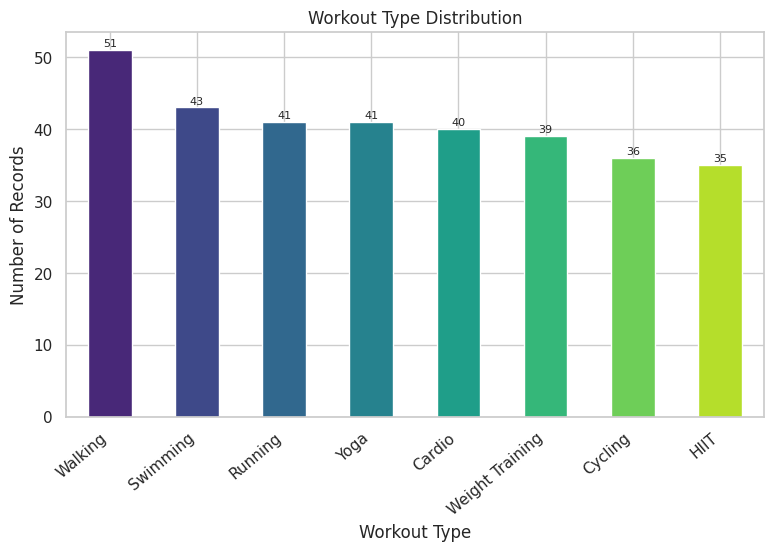

In [62]:
fig, ax = plt.subplots(figsize=(9, 5))
workout_counts.sort_values(ascending=False).plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(workout_counts)))
ax.set_title("Workout Type Distribution")
ax.set_xlabel("Workout Type")
ax.set_ylabel("Number of Records")
for i, v in enumerate(workout_counts.sort_values(ascending=False)):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=8)
plt.xticks(rotation=40, ha="right")
save_chart(fig, "01_workout_type_distribution.png")

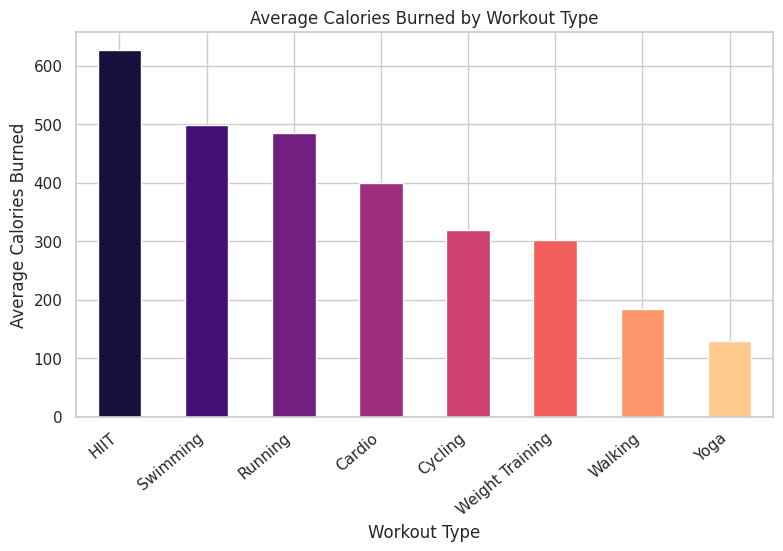

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
avg_cal_by_type.plot(kind="bar", ax=ax, color=sns.color_palette("magma", len(avg_cal_by_type)))
ax.set_title("Average Calories Burned by Workout Type")
ax.set_xlabel("Workout Type")
ax.set_ylabel("Average Calories Burned")
plt.xticks(rotation=40, ha="right")
save_chart(fig, "02_calories_by_workout_type.png")

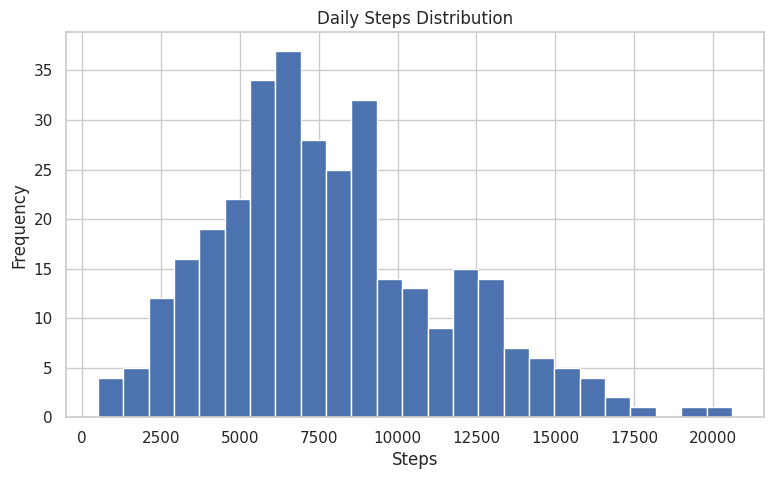

In [64]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Steps"], bins=25, color="#4C72B0", edgecolor="white")
ax.set_title("Daily Steps Distribution")
ax.set_xlabel("Steps")
ax.set_ylabel("Frequency")
save_chart(fig, "03_daily_steps_distribution.png")

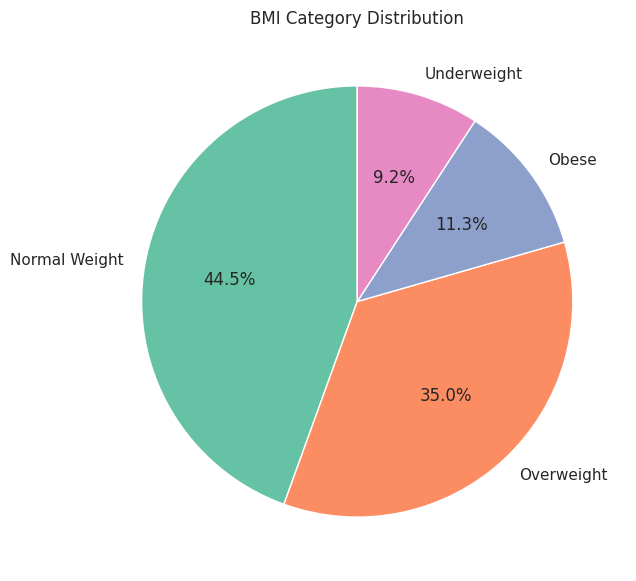

In [65]:
fig, ax = plt.subplots(figsize=(7, 7))
bmi_cat_counts = df["BMI Category"].value_counts()
ax.pie(bmi_cat_counts, labels=bmi_cat_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2"), startangle=90)
ax.set_title("BMI Category Distribution")
save_chart(fig, "04_bmi_category_distribution.png")

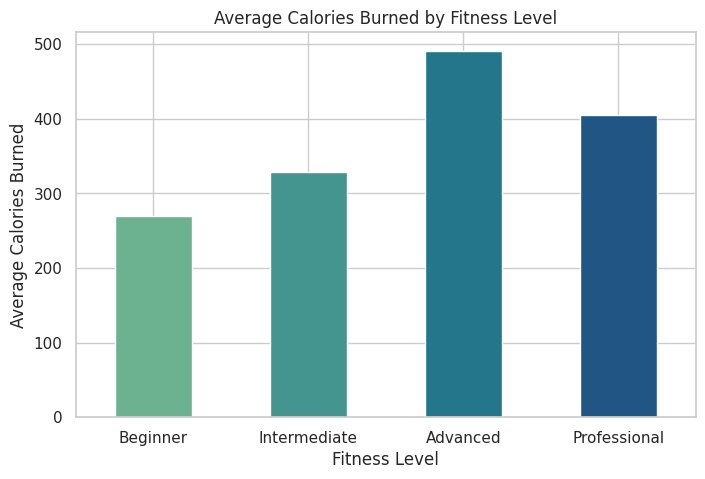

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))
fl_summary["Avg_Calories"].plot(kind="bar", ax=ax, color=sns.color_palette("crest", 4))
ax.set_title("Average Calories Burned by Fitness Level")
ax.set_xlabel("Fitness Level")
ax.set_ylabel("Average Calories Burned")
plt.xticks(rotation=0)
save_chart(fig, "05_avg_calories_by_fitness_level.png")

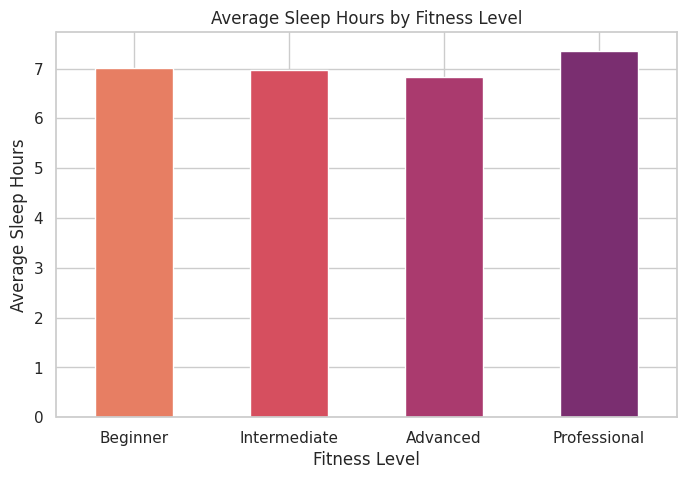

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
fl_summary["Avg_Sleep"].plot(kind="bar", ax=ax, color=sns.color_palette("flare", 4))
ax.set_title("Average Sleep Hours by Fitness Level")
ax.set_xlabel("Fitness Level")
ax.set_ylabel("Average Sleep Hours")
plt.xticks(rotation=0)
save_chart(fig, "06_avg_sleep_by_fitness_level.png")

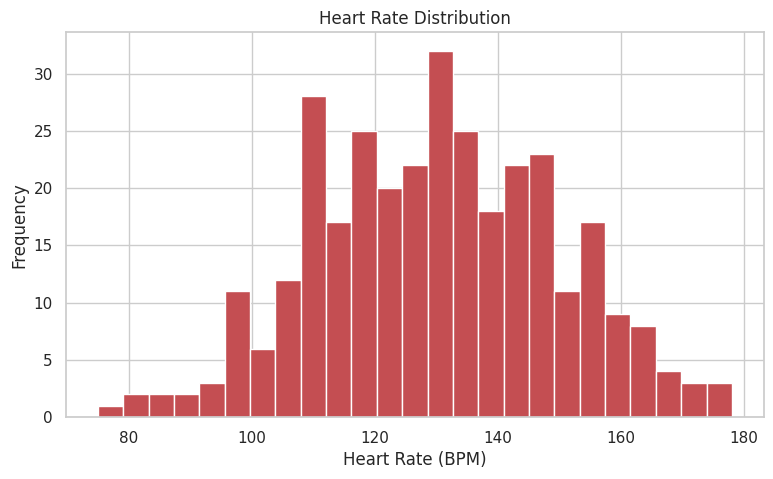

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Heart Rate (BPM)"], bins=25, color="#C44E52", edgecolor="white")
ax.set_title("Heart Rate Distribution")
ax.set_xlabel("Heart Rate (BPM)")
ax.set_ylabel("Frequency")
save_chart(fig, "07_heart_rate_distribution.png")

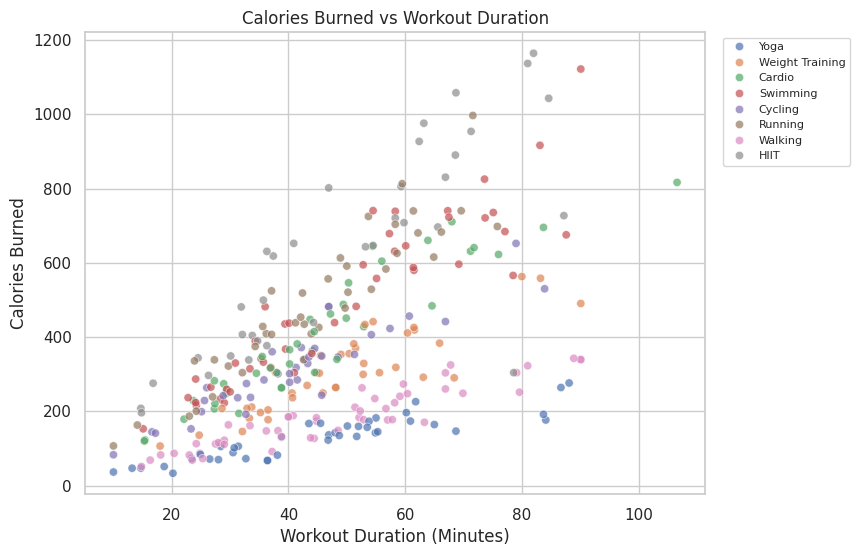

In [69]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="Workout Duration (Minutes)", y="Calories Burned",
                 hue="Workout Type", alpha=0.7, ax=ax)
ax.set_title("Calories Burned vs Workout Duration")
ax.set_xlabel("Workout Duration (Minutes)")
ax.set_ylabel("Calories Burned")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
save_chart(fig, "08_calories_vs_duration.png")

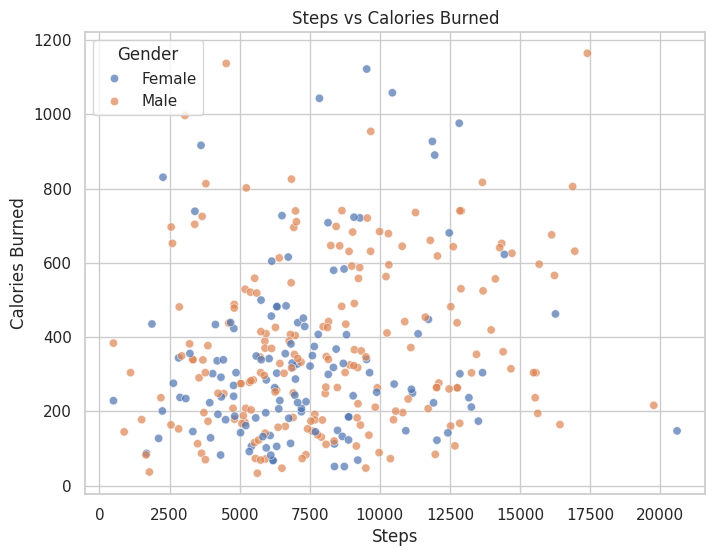

In [70]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="Steps", y="Calories Burned", hue="Gender", alpha=0.7, ax=ax)
ax.set_title("Steps vs Calories Burned")
ax.set_xlabel("Steps")
ax.set_ylabel("Calories Burned")
save_chart(fig, "09_steps_vs_calories.png")

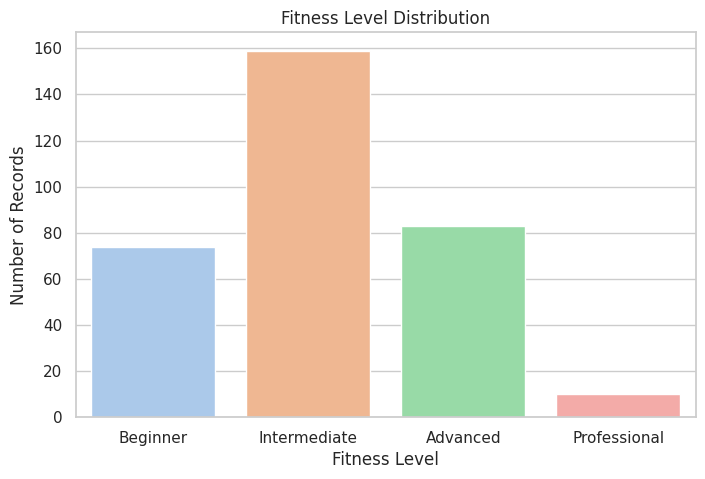

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="Fitness Level", order=fitness_order, palette="pastel", ax=ax)
ax.set_title("Fitness Level Distribution")
ax.set_xlabel("Fitness Level")
ax.set_ylabel("Number of Records")
save_chart(fig, "10_fitness_level_distribution.png")

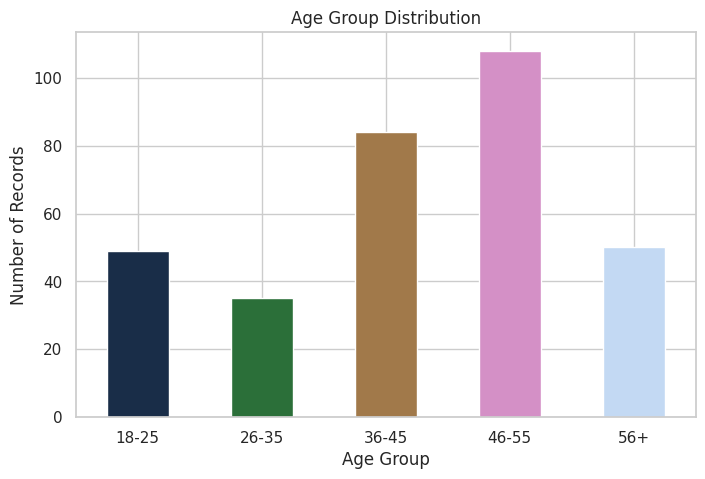

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
age_group_counts.plot(kind="bar", ax=ax, color=sns.color_palette("cubehelix", 5))
ax.set_title("Age Group Distribution")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=0)
save_chart(fig, "11_age_group_distribution.png")

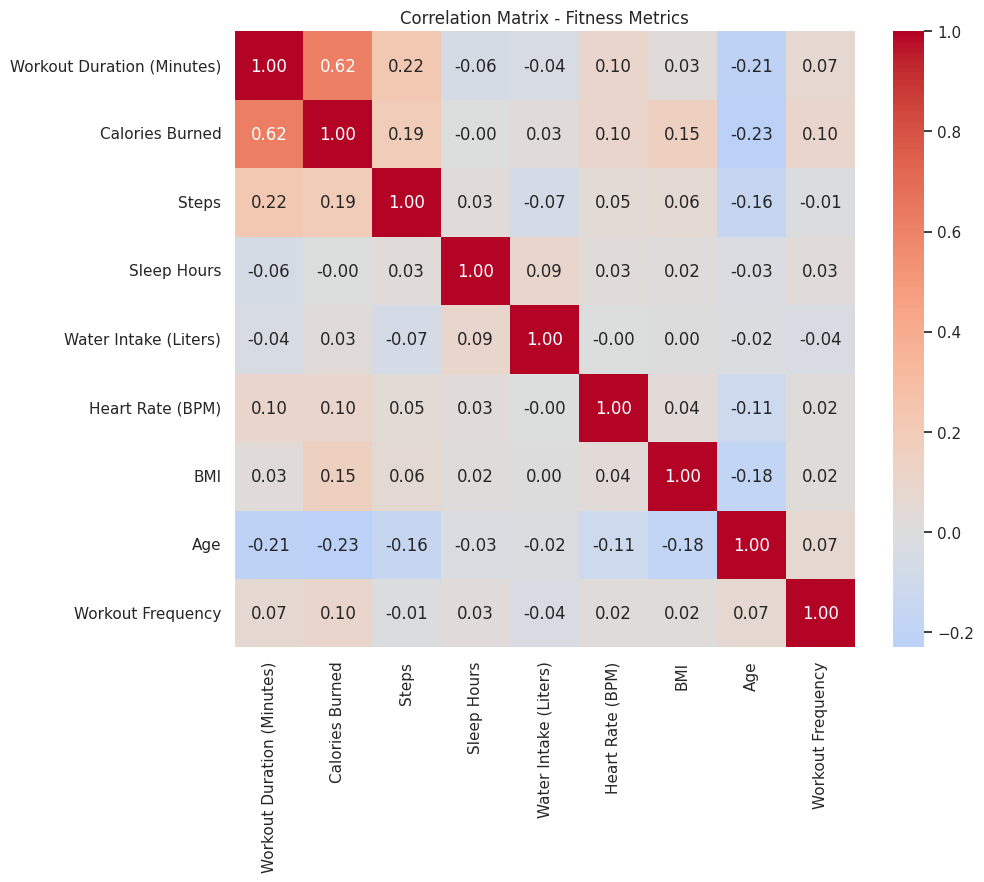

In [73]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix - Fitness Metrics")
save_chart(fig, "12_correlation_matrix_heatmap.png")

In [74]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

df["Fitness Score"] = (
    normalize(df["Calories Burned"]) * 30 +
    normalize(df["Steps"]) * 25 +
    normalize(df["Workout Duration (Minutes)"]) * 20 +
    normalize(df["Workout Frequency"]) * 15 +
    normalize(df["Sleep Hours"]) * 10
).round(2)

df["Fitness Rank"] = df["Fitness Score"].rank(ascending=False, method="min").astype(int)

print("Top 10 users by fitness score:")
df.nsmallest(10, "Fitness Rank")[["User Name", "Fitness Score", "Fitness Rank"]]

Top 10 users by fitness score:


User Name  Fitness Score  Fitness Rank
20        Komal Khan          78.73             1
266        Sara Shah          76.98             2
232     Ayesha Malik          74.20             3
201  Kamran Chaudhry          73.64             4
117  Kamran Chaudhry          70.56             5
229  Kamran Chaudhry          66.25             6
309    Ayesha Farooq          64.93             7
278     Faisal Ahmed          64.64             8
170       Imran Butt          64.57             9
297      Tariq Malik          64.54            10

In [76]:
df["Year"] = df["Activity Date"].dt.year
df["Month"] = df["Activity Date"].dt.month
df["Day"] = df["Activity Date"].dt.day
df["Day of Week"] = df["Activity Date"].dt.day_name()

monthly_counts = df["Month"].value_counts().sort_index()
print(monthly_counts)

Month
1     27
2     20
3     34
4     32
5     23
6     23
7     25
8     25
9     33
10    32
11    19
12    33
Name: count, dtype: int64


In [77]:
monthly_calories = df.groupby("Month")["Calories Burned"].sum().round(1)
monthly_duration = df.groupby("Month")["Workout Duration (Minutes)"].mean().round(2)

print("Total calories by month:")
print(monthly_calories)
print("\nAverage duration by month:")
print(monthly_duration)

print("\nMonth with highest activity:", int(monthly_counts.idxmax()))
print("Month with highest total calories:", int(monthly_calories.idxmax()))

Total calories by month:
Month
1      8737.0
2      7747.0
3     15017.1
4     12575.5
5      8418.2
6      8136.6
7      8253.8
8      9122.0
9     10216.5
10    10453.8
11     7117.2
12    11305.1
Name: Calories Burned, dtype: float64

Average duration by month:
Month
1     44.88
2     44.40
3     46.27
4     54.54
5     46.67
6     45.47
7     46.40
8     48.62
9     39.95
10    47.13
11    48.11
12    45.83
Name: Workout Duration (Minutes), dtype: float64

Month with highest activity: 3
Month with highest total calories: 3


In [79]:
weekday_mask = ~df["Day of Week"].isin(["Saturday", "Sunday"])
weekday_avg = df[weekday_mask]["Calories Burned"].mean()
weekend_avg = df[~weekday_mask]["Calories Burned"].mean()
print("Average calories - weekdays:", round(weekday_avg, 2))
print("Average calories - weekends:", round(weekend_avg, 2))

dow_counts = df["Day of Week"].value_counts()
print("Most active day of week:", dow_counts.idxmax())

print("\nMonthly fitness trend (avg calories per month):")
print(df.groupby("Month")["Calories Burned"].mean().round(2))

Average calories - weekdays: 354.21
Average calories - weekends: 370.98
Most active day of week: Sunday

Monthly fitness trend (avg calories per month):
Month
1     323.59
2     387.35
3     441.68
4     392.98
5     366.01
6     353.77
7     330.15
8     364.88
9     309.59
10    326.68
11    374.59
12    342.58
Name: Calories Burned, dtype: float64


In [80]:
output_csv = "analyzed_fitness_health_data.csv"
df.to_csv(output_csv, index=False)
print("Saved:", output_csv)

top_fitness_user = df.loc[df["Fitness Score"].idxmax(), "User Name"]

summary = {
    "Total Users": df["User ID"].nunique(),
    "Total Records": len(df),
    "Average Age": round(df["Age"].mean(), 2),
    "Average BMI": round(df["BMI"].mean(), 2),
    "Average Calories Burned": round(df["Calories Burned"].mean(), 2),
    "Average Workout Duration (min)": round(df["Workout Duration (Minutes)"].mean(), 2),
    "Average Daily Steps": round(df["Steps"].mean(), 0),
    "Average Sleep Hours": round(df["Sleep Hours"].mean(), 2),
    "Average Water Intake (L)": round(df["Water Intake (Liters)"].mean(), 2),
    "Most Popular Workout": workout_counts.idxmax(),
    "Most Common Fitness Level": fl_counts.idxmax(),
    "Most Active Age Group": most_active_age_group,
    "Highest Performing City": top_activity_city,
    "Top Fitness User": top_fitness_user,
    "Average Fitness Score": round(df["Fitness Score"].mean(), 2),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df.to_csv("fitness_summary.csv", index=False)
summary_df

Saved: analyzed_fitness_health_data.csv


Metric         Value
0                      Total Users            60
1                    Total Records           326
2                      Average Age         42.57
3                      Average BMI         24.49
4          Average Calories Burned         359.2
5   Average Workout Duration (min)         46.52
6              Average Daily Steps        7880.0
7              Average Sleep Hours          6.96
8         Average Water Intake (L)          2.43
9             Most Popular Workout       Walking
10       Most Common Fitness Level  Intermediate
11           Most Active Age Group         26-35
12         Highest Performing City        Quetta
13                Top Fitness User    Komal Khan
14           Average Fitness Score         39.38

In [81]:
import zipfile
from pathlib import Path

zip_name = "fitness_analysis_outputs.zip"
with zipfile.ZipFile(zip_name, "w") as zf:
    zf.write("analyzed_fitness_health_data.csv")
    zf.write("fitness_summary.csv")
    for chart_file in Path("charts").glob("*.png"):
        zf.write(chart_file)

print(f"Created {zip_name}")

try:
    from google.colab import files
    files.download(zip_name)
except ImportError:
    print(f"Saved at: {Path(zip_name).resolve()}")

Created fitness_analysis_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>